# Recommendation Systems in Practice

This notebook is a polished, self-contained walkthrough of core recommendation strategies. It avoids external downloads so the examples stay easy to run and easy to understand.

## What we cover
- Build a small movie recommendation dataset
- Explore sparsity in the user-item matrix
- Create a popularity-based baseline
- Build a content-based recommender from genres and keywords
- Combine both approaches into a simple hybrid system
- Evaluate recommendations with a lightweight precision@k check

## Why recommendation systems matter

Recommendation systems help users discover relevant items in large catalogs. In practice, strong systems usually combine several signals:

1. **Popularity** for robust defaults
2. **Content similarity** for interpretable recommendations
3. **Personalized signals** from user behavior
4. **Evaluation metrics** that focus on ranking quality rather than only error reduction

This notebook keeps the data small on purpose so every step is transparent.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('default')
pd.set_option('display.max_colwidth', 100)
np.set_printoptions(suppress=True)


def cosine_similarity_matrix(matrix: np.ndarray) -> np.ndarray:
    """Compute a cosine similarity matrix row-wise without external dependencies."""
    matrix = np.asarray(matrix, dtype=float)
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    normalized = matrix / norms
    return normalized @ normalized.T


print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
movies = pd.DataFrame([
    (1, 'Toy Story', 'Animation|Adventure|Comedy', 'family|friendship|toys'),
    (2, 'The Matrix', 'Action|Sci-Fi', 'virtual reality|ai|dystopia'),
    (3, 'Finding Nemo', 'Animation|Adventure', 'ocean|family|journey'),
    (4, 'Interstellar', 'Adventure|Drama|Sci-Fi', 'space|time|survival'),
    (5, 'The Dark Knight', 'Action|Crime|Drama', 'hero|crime|gotham'),
    (6, 'La La Land', 'Comedy|Drama|Romance', 'music|dreams|love'),
    (7, 'Inception', 'Action|Sci-Fi|Thriller', 'dreams|mind-bending|heist'),
    (8, 'Coco', 'Animation|Family|Fantasy', 'music|family|memory'),
    (9, 'The Godfather', 'Crime|Drama', 'mafia|family|power'),
    (10, 'Arrival', 'Drama|Sci-Fi', 'language|aliens|time')
], columns=['movie_id', 'title', 'genres', 'keywords'])

ratings = pd.DataFrame([
    (1, 1, 5, 1), (1, 3, 4, 2), (1, 8, 5, 3), (1, 6, 3, 4),
    (2, 2, 5, 1), (2, 7, 5, 2), (2, 4, 4, 3), (2, 10, 4, 4),
    (3, 5, 5, 1), (3, 9, 5, 2), (3, 2, 4, 3), (3, 7, 4, 4),
    (4, 6, 5, 1), (4, 1, 4, 2), (4, 8, 4, 3), (4, 3, 3, 4),
    (5, 4, 5, 1), (5, 10, 5, 2), (5, 2, 4, 3), (5, 7, 4, 4),
    (6, 3, 5, 1), (6, 8, 4, 2), (6, 1, 4, 3), (6, 6, 2, 4),
    (7, 9, 5, 1), (7, 5, 4, 2), (7, 4, 4, 3), (7, 10, 3, 4),
    (8, 1, 4, 1), (8, 6, 5, 2), (8, 8, 5, 3), (8, 3, 4, 4)
], columns=['user_id', 'movie_id', 'rating', 'timestamp'])

print('Movies:', len(movies))
print('Ratings:', len(ratings))
movies.head()

Movies: 10
Ratings: 32


,movie_id,title,genres,keywords
0,1,Toy Story,Animation|Adventure|Comedy,family|friendship|toys
1,2,The Matrix,Action|Sci-Fi,virtual reality|ai|dystopia
2,3,Finding Nemo,Animation|Adventure,ocean|family|journey
3,4,Interstellar,Adventure|Drama|Sci-Fi,space|time|survival
4,5,The Dark Knight,Action|Crime|Drama,hero|crime|gotham


User-item matrix shape: (8, 10)
Observed ratings: 32
Possible ratings: 80
Sparsity: 60.0%


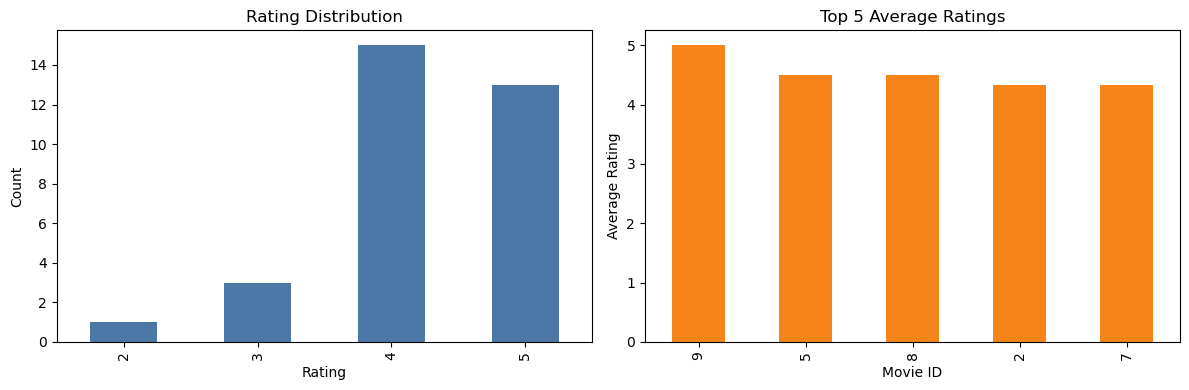

movie_id,1,2,3,4,5,6,7,8,9,10
user_id,,,,,,,,,,
1,5.0,0.0,4.0,0.0,0.0,3.0,0.0,5.0,0.0,0.0
2,0.0,5.0,0.0,4.0,0.0,0.0,5.0,0.0,0.0,4.0
3,0.0,4.0,0.0,0.0,5.0,0.0,4.0,0.0,5.0,0.0
4,4.0,0.0,3.0,0.0,0.0,5.0,0.0,4.0,0.0,0.0
5,0.0,4.0,0.0,5.0,0.0,0.0,4.0,0.0,0.0,5.0
6,4.0,0.0,5.0,0.0,0.0,2.0,0.0,4.0,0.0,0.0
7,0.0,0.0,0.0,4.0,4.0,0.0,0.0,0.0,5.0,3.0
8,4.0,0.0,4.0,0.0,0.0,5.0,0.0,5.0,0.0,0.0


In [3]:
user_item = ratings.pivot_table(index='user_id', columns='movie_id', values='rating', fill_value=0)

n_users, n_items = user_item.shape
observed_ratings = (user_item > 0).sum().sum()
all_possible = n_users * n_items
sparsity = 1 - observed_ratings / all_possible

print(f'User-item matrix shape: {user_item.shape}')
print(f'Observed ratings: {observed_ratings}')
print(f'Possible ratings: {all_possible}')
print(f'Sparsity: {sparsity:.1%}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ratings['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#4C78A8')
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

ratings.groupby('movie_id')['rating'].mean().sort_values(ascending=False).head(5).plot(
    kind='bar', ax=axes[1], color='#F58518'
)
axes[1].set_title('Top 5 Average Ratings')
axes[1].set_xlabel('Movie ID')
axes[1].set_ylabel('Average Rating')

plt.tight_layout()
plt.show()

user_item

## 1. Popularity baseline

A popularity baseline is simple, stable, and surprisingly useful. It does not personalize recommendations, but it gives us a strong default and a helpful benchmark.

In [4]:
movie_stats = (
    ratings.groupby('movie_id')
    .agg(avg_rating=('rating', 'mean'), rating_count=('rating', 'size'))
    .reset_index()
    .merge(movies[['movie_id', 'title', 'genres']], on='movie_id', how='left')
)

movie_stats['popularity_score'] = movie_stats['avg_rating'] * np.log1p(movie_stats['rating_count'])
popular_recommendations = movie_stats.sort_values('popularity_score', ascending=False)

popular_recommendations[['title', 'avg_rating', 'rating_count', 'popularity_score']].head(5)

,title,avg_rating,rating_count,popularity_score
7,Coco,4.500000,4,7.242471
0,Toy Story,4.250000,4,6.840111
2,Finding Nemo,4.000000,4,6.437752
5,La La Land,3.750000,4,6.035392
1,The Matrix,4.333333,3,6.007276


## 2. Content-based recommendations

Here we represent each movie using interpretable features from genres and keywords. Similar items receive higher cosine similarity scores.

In [5]:
genre_features = movies['genres'].str.get_dummies(sep='|')
keyword_features = movies['keywords'].str.get_dummies(sep='|')
item_features = pd.concat([genre_features, keyword_features], axis=1)
item_features.index = movies['movie_id']

similarity_matrix = cosine_similarity_matrix(item_features.values)
item_similarity = pd.DataFrame(similarity_matrix, index=movies['movie_id'], columns=movies['movie_id'])


def similar_movies(title: str, top_n: int = 5) -> pd.DataFrame:
    movie_row = movies.loc[movies['title'] == title]
    if movie_row.empty:
        raise ValueError(f'Movie not found: {title}')

    movie_id = int(movie_row['movie_id'].iloc[0])
    scores = (
        item_similarity.loc[movie_id]
        .drop(index=movie_id)
        .sort_values(ascending=False)
        .head(top_n)
        .rename('similarity_score')
        .reset_index()
    )
    return scores.merge(movies[['movie_id', 'title', 'genres']], on='movie_id', how='left')

similar_movies('Interstellar', top_n=5)


,movie_id,similarity_score,title,genres
0,10,0.547723,Arrival,Drama|Sci-Fi
1,9,0.182574,The Godfather,Crime|Drama
2,2,0.182574,The Matrix,Action|Sci-Fi
3,3,0.182574,Finding Nemo,Animation|Adventure
4,1,0.166667,Toy Story,Animation|Adventure|Comedy


In [6]:
def min_max_scale(series: pd.Series) -> pd.Series:
    minimum = series.min()
    maximum = series.max()
    if maximum == minimum:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - minimum) / (maximum - minimum)


def recommend_for_user(user_id: int, top_n: int = 5, alpha: float = 0.7) -> pd.DataFrame:
    user_history = ratings.loc[ratings['user_id'] == user_id, ['movie_id', 'rating']]
    if user_history.empty:
        raise ValueError(f'User not found: {user_id}')

    seen_movie_ids = set(user_history['movie_id'])
    candidate_movies = movies.loc[~movies['movie_id'].isin(seen_movie_ids), ['movie_id', 'title', 'genres']].copy()

    weighted_profile = np.average(
        item_features.loc[user_history['movie_id']].values,
        axis=0,
        weights=user_history['rating'].values
    )

    content_scores = item_features.loc[candidate_movies['movie_id']].values @ weighted_profile
    content_scores = pd.Series(content_scores, index=candidate_movies['movie_id'])

    popularity_scores = movie_stats.set_index('movie_id').loc[candidate_movies['movie_id'], 'popularity_score']

    candidate_movies['content_score'] = min_max_scale(content_scores).values
    candidate_movies['popularity_score'] = min_max_scale(popularity_scores).values
    candidate_movies['hybrid_score'] = (
        alpha * candidate_movies['content_score']
        + (1 - alpha) * candidate_movies['popularity_score']
    )

    return candidate_movies.sort_values('hybrid_score', ascending=False).head(top_n)

recommend_for_user(user_id=2, top_n=5, alpha=0.7)

,movie_id,title,genres,content_score,popularity_score,hybrid_score
4,5,The Dark Knight,Action|Crime|Drama,1.000000,0.000000,0.700000
5,6,La La Land,Comedy|Drama|Romance,0.722222,0.474890,0.648023
0,1,Toy Story,Animation|Adventure|Comedy,0.222222,0.824963,0.403045
8,9,The Godfather,Crime|Drama,0.444444,0.238962,0.382800
2,3,Finding Nemo,Animation|Adventure,0.222222,0.649927,0.350534


## 3. Lightweight evaluation

A simple offline check is to hold out the latest interaction for each user and see whether the recommender places that item inside the top-k results.

In [7]:
test_rows = ratings.sort_values('timestamp').groupby('user_id').tail(1)
train_ratings = ratings.drop(index=test_rows.index).copy()

train_movie_stats = (
    train_ratings.groupby('movie_id')
    .agg(avg_rating=('rating', 'mean'), rating_count=('rating', 'size'))
    .reset_index()
)
train_movie_stats['popularity_score'] = train_movie_stats['avg_rating'] * np.log1p(train_movie_stats['rating_count'])
train_movie_stats = train_movie_stats.set_index('movie_id')


def recommend_from_train(user_id: int, top_n: int = 3, alpha: float = 0.7) -> list:
    user_history = train_ratings.loc[train_ratings['user_id'] == user_id, ['movie_id', 'rating']]
    if user_history.empty:
        return []

    seen_movie_ids = set(user_history['movie_id'])
    candidate_ids = [mid for mid in movies['movie_id'] if mid not in seen_movie_ids]
    if not candidate_ids:
        return []

    weighted_profile = np.average(
        item_features.loc[user_history['movie_id']].values,
        axis=0,
        weights=user_history['rating'].values
    )

    content_scores = pd.Series(
        item_features.loc[candidate_ids].values @ weighted_profile,
        index=candidate_ids,
        dtype=float
    )

    popularity_scores = train_movie_stats.reindex(candidate_ids)['popularity_score'].fillna(0.0)

    blended = alpha * min_max_scale(content_scores) + (1 - alpha) * min_max_scale(popularity_scores)
    return blended.sort_values(ascending=False).head(top_n).index.tolist()


hits = []
for row in test_rows.itertuples(index=False):
    predicted_items = recommend_from_train(user_id=row.user_id, top_n=3, alpha=0.7)
    hits.append(int(row.movie_id in predicted_items))

precision_at_3 = np.mean(hits) / 3
recall_at_3 = np.mean(hits)

print(f'Evaluated users: {len(hits)}')
print(f'Hit rate @3: {np.mean(hits):.2f}')
print(f'Precision @3: {precision_at_3:.2f}')
print(f'Recall @3: {recall_at_3:.2f}')

Evaluated users: 8
Hit rate @3: 1.00
Precision @3: 0.33
Recall @3: 1.00


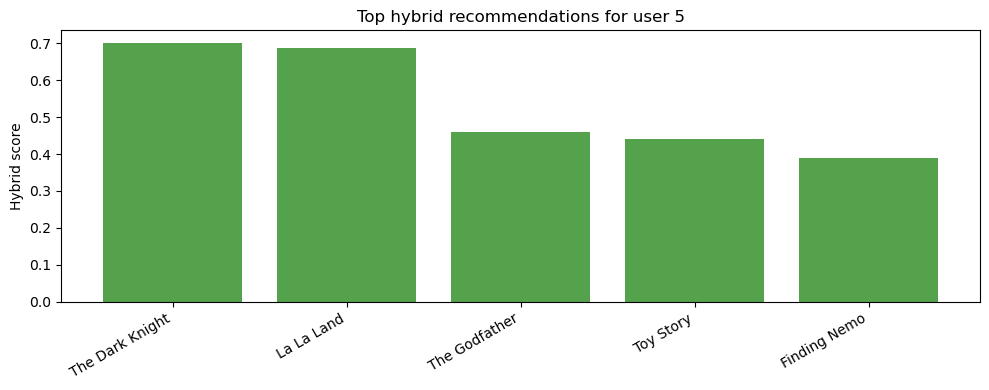

,movie_id,title,genres,content_score,popularity_score,hybrid_score
4,5,The Dark Knight,Action|Crime|Drama,1.000000,0.000000,0.700000
5,6,La La Land,Comedy|Drama|Romance,0.777778,0.474890,0.686911
8,9,The Godfather,Crime|Drama,0.555556,0.238962,0.460578
0,1,Toy Story,Animation|Adventure|Comedy,0.277778,0.824963,0.441933
2,3,Finding Nemo,Animation|Adventure,0.277778,0.649927,0.389422


In [8]:
sample_user = 5
sample_recommendations = recommend_for_user(sample_user, top_n=5, alpha=0.7)

plt.figure(figsize=(10, 4))
plt.bar(sample_recommendations['title'], sample_recommendations['hybrid_score'], color='#54A24B')
plt.title(f'Top hybrid recommendations for user {sample_user}')
plt.ylabel('Hybrid score')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

sample_recommendations

## Key takeaways

- The data is sparse even in a tiny example, which is why recommendation problems are different from standard supervised learning.
- A popularity baseline is easy to build and useful as a fallback.
- Content-based features make recommendations interpretable and do not require large volumes of user history.
- Hybrid ranking often works better than relying on a single signal.
- Evaluation should focus on the ranked list users actually see.

## Suggested next steps
- Add user-user or item-item collaborative filtering
- Tune the hybrid weight on a validation split
- Replace the toy dataset with your real catalog and feedback logs